#Project 4: Spotify Music Popularity Prediction


##Problem Definition


This is a **Supervised** **Regression** problem and we'll be using the tree-based regression model to make the predictions on how **popular** a song will be. We'll also be using Random Forest and XGBoost ***regularization techniques to reduce overfitting and for feature selection.*** Our performance metric will be Cross-validated Root Mean Squared Error (**RMSE**).

##Data Collection

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
#Set the URL
url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv"
url

'https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv'

In [ ]:
df = pd.read_csv(url)
df

,Index,Highest Charting Position,Number of Times Charted,Week of Highest Charting,Song Name,Streams,Artist,Artist Followers,Song ID,Genre,...,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence,Chord
0,1,1,8,2021-07-23--2021-07-30,Beggin',"48,633,449",Måneskin,3377762,3Wrjm47oTz2sjIgck11l5e,"['indie rock italiano', 'italian pop']",...,0.714,0.8,-4.808,0.0504,0.127,0.359,134.002,211560,0.589,B
1,2,2,3,2021-07-23--2021-07-30,STAY (with Justin Bieber),"47,248,719",The Kid LAROI,2230022,5HCyWlXZPP0y6Gqq8TgA20,['australian hip hop'],...,0.591,0.764,-5.484,0.0483,0.0383,0.103,169.928,141806,0.478,C#/Db
2,3,1,11,2021-06-25--2021-07-02,good 4 u,"40,162,559",Olivia Rodrigo,6266514,4ZtFanR9U6ndgddUvNcjcG,['pop'],...,0.563,0.664,-5.044,0.154,0.335,0.0849,166.928,178147,0.688,A
3,4,3,5,2021-07-02--2021-07-09,Bad Habits,"37,799,456",Ed Sheeran,83293380,6PQ88X9TkUIAUIZJHW2upE,"['pop', 'uk pop']",...,0.808,0.897,-3.712,0.0348,0.0469,0.364,126.026,231041,0.591,B
4,5,5,1,2021-07-23--2021-07-30,INDUSTRY BABY (feat. Jack Harlow),"33,948,454",Lil Nas X,5473565,27NovPIUIRrOZoCHxABJwK,"['lgbtq+ hip hop', 'pop rap']",...,0.736,0.704,-7.409,0.0615,0.0203,0.0501,149.995,212000,0.894,D#/Eb
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1551,1552,195,1,2019-12-27--2020-01-03,New Rules,"4,630,675",Dua Lipa,27167675,2ekn2ttSfGqwhhate0LSR0,"['dance pop', 'pop', 'uk pop']",...,0.762,0.7,-6.021,0.0694,0.00261,0.153,116.073,209320,0.608,A
1552,1553,196,1,2019-12-27--2020-01-03,Cheirosa - Ao Vivo,"4,623,030",Jorge & Mateus,15019109,2PWjKmjyTZeDpmOUa3a5da,"['sertanejo', 'sertanejo universitario']",...,0.528,0.87,-3.123,0.0851,0.24,0.333,152.37,181930,0.714,B
1553,1554,197,1,2019-12-27--2020-01-03,Havana (feat. Young Thug),"4,620,876",Camila Cabello,22698747,1rfofaqEpACxVEHIZBJe6W,"['dance pop', 'electropop', 'pop', 'post-teen ...",...,0.765,0.523,-4.333,0.03,0.184,0.132,104.988,217307,0.394,D
1554,1555,198,1,2019-12-27--2020-01-03,Surtada - Remix Brega Funk,"4,607,385","Dadá Boladão, Tati Zaqui, OIK",208630,5F8ffc8KWKNawllr5WsW0r,"['brega funk', 'funk carioca']",...,0.832,0.55,-7.026,0.0587,0.249,0.182,154.064,152784,0.881,F


##Data Cleaning

In [ ]:
df.shape

(1556, 23)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1556 entries, 0 to 1555
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Index                      1556 non-null   int64 
 1   Highest Charting Position  1556 non-null   int64 
 2   Number of Times Charted    1556 non-null   int64 
 3   Week of Highest Charting   1556 non-null   object
 4   Song Name                  1556 non-null   object
 5   Streams                    1556 non-null   object
 6   Artist                     1556 non-null   object
 7   Artist Followers           1556 non-null   object
 8   Song ID                    1556 non-null   object
 9   Genre                      1556 non-null   object
 10  Release Date               1556 non-null   object
 11  Weeks Charted              1556 non-null   object
 12  Popularity                 1556 non-null   object
 13  Danceability               1556 non-null   object
 14  Energy  

In [ ]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Index,1556.0,778.500000,449.322824,1.0,389.75,778.5,1167.25,1556.0
Highest Charting Position,1556.0,87.744216,58.147225,1.0,37.00,80.0,137.00,200.0
Number of Times Charted,1556.0,10.668380,16.360546,1.0,1.00,4.0,12.00,142.0


In [ ]:
df.isnull().sum()*1000

,0
Index,0
Highest Charting Position,0
Number of Times Charted,0
Week of Highest Charting,0
Song Name,0
Streams,0
Artist,0
Artist Followers,0
Song ID,0
Genre,0


###Target

Possible targets:
- Streams
- Popularity 1-100

Other possible (but not likely) targets:
- Highest Charting Position
- Number of Times Charted
- Week of Highest Charting
- Weeks Charted

In [ ]:
target = 'Streams'

In [ ]:
#View target
df[target].sort_values()

,Streams
1380,"10,016,907"
479,"10,024,729"
48,"10,032,746"
1278,"10,058,303"
1487,"10,086,930"
...,...
633,"9,882,989"
257,"9,889,197"
1197,"9,904,749"
1330,"9,974,143"


In [ ]:
#Look to see if there are nulls in target
df[target].isnull().sum()

np.int64(0)

In [ ]:
#Check the dtype
df[target].dtype

dtype('O')

In [ ]:
df[target] = df[target].str.replace(',', '').astype(int)

In [ ]:
df[target].dtype

dtype('int64')

In [ ]:
df[target]

,Streams
0,48633449
1,47248719
2,40162559
3,37799456
4,33948454
...,...
1551,4630675
1552,4623030
1553,4620876
1554,4607385


In [ ]:
df[target].isnull().sum()

np.int64(0)

In [ ]:
df[target].describe().transpose()

,Streams
count,1.556000e+03
mean,6.340219e+06
std,3.369479e+06
min,4.176083e+06
25%,4.915322e+06
50%,5.275748e+06
75%,6.455044e+06
max,4.863345e+07


###Rows

In [ ]:
#Rows with nulls
df.isnull().any(axis = 1).sum()

np.int64(0)

In [ ]:
#Missing rows
df.isnull().sum().sort_values()

,0
Index,0
Highest Charting Position,0
Number of Times Charted,0
Week of Highest Charting,0
Song Name,0
Streams,0
Artist,0
Artist Followers,0
Song ID,0
Genre,0


In [ ]:
#Duplicate rows
df.duplicated().sum()

np.int64(0)

###Columns

Important features from Random Tree

INT
- Duration (ms)

Flt
- Tempo
- Liveness



In [ ]:
features = df[['Duration (ms)', 'Tempo', 'Liveness']]
features

,Duration (ms),Tempo,Liveness
0,211560,134.002,0.359
1,141806,169.928,0.103
2,178147,166.928,0.0849
3,231041,126.026,0.364
4,212000,149.995,0.0501
...,...,...,...
1551,209320,116.073,0.153
1552,181930,152.37,0.333
1553,217307,104.988,0.132
1554,152784,154.064,0.182


####Integers

In [ ]:
integer = 'Duration (ms)'

In [ ]:
df[integer].sort_values(ascending=True)

,Duration (ms)
654,
530,
1140,
464,
35,
...,...
391,80081
670,85267
664,86760
260,88625


In [ ]:
df[integer] = pd.to_numeric(
  df[integer],
  errors='coerce'
)

df[integer].sort_values(ascending=True)

,Duration (ms)
1499,30133.0
1030,30583.0
711,37013.0
1137,41867.0
1135,41867.0
...,...
750,NaN
784,NaN
876,NaN
1140,NaN


In [ ]:
df[integer].dtype

dtype('float64')

In [ ]:
df[integer] = df[integer].fillna(0).astype(int)

df[integer].sort_values(ascending=True)

,Duration (ms)
1538,0
530,0
464,0
1140,0
163,0
...,...
274,393280
1335,457592
757,484147
265,515865


In [ ]:
df[integer].isna().sum()

np.int64(0)

####Floats

In [ ]:
floats = [
  'Liveness',
  'Tempo'
]

In [ ]:
df[floats] = df[floats].apply(pd.to_numeric, errors='coerce')
df[floats]

,Liveness,Tempo
0,0.3590,134.002
1,0.1030,169.928
2,0.0849,166.928
3,0.3640,126.026
4,0.0501,149.995
...,...,...
1551,0.1530,116.073
1552,0.3330,152.370
1553,0.1320,104.988
1554,0.1820,154.064


In [ ]:
df[floats].dtypes

,0
Liveness,float64
Tempo,float64


In [ ]:
df[floats].isnull().sum()

,0
Liveness,11
Tempo,11


In [ ]:
df[floats].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Liveness,1545.0,0.181202,0.144071,0.0197,0.0966,0.124,0.217,0.962
Tempo,1545.0,122.811023,29.591088,46.7180,97.9600,122.012,143.860,205.272


####Imputation

In [ ]:
df[floats] = df[floats].fillna(0)

In [ ]:
df[floats].isnull().sum()

,0
Liveness,0
Tempo,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1556 entries, 0 to 1555
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Index                      1556 non-null   int64  
 1   Highest Charting Position  1556 non-null   int64  
 2   Number of Times Charted    1556 non-null   int64  
 3   Week of Highest Charting   1556 non-null   object 
 4   Song Name                  1556 non-null   object 
 5   Streams                    1556 non-null   int64  
 6   Artist                     1556 non-null   object 
 7   Artist Followers           1556 non-null   object 
 8   Song ID                    1556 non-null   object 
 9   Genre                      1556 non-null   object 
 10  Release Date               1556 non-null   object 
 11  Weeks Charted              1556 non-null   object 
 12  Popularity                 1556 non-null   object 
 13  Danceability               1556 non-null   objec

###Keep

In [ ]:
df_clean = df[['Streams', 'Duration (ms)', 'Tempo', 'Liveness']]

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1556 entries, 0 to 1555
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Streams        1556 non-null   int64  
 1   Duration (ms)  1556 non-null   int64  
 2   Tempo          1556 non-null   float64
 3   Liveness       1556 non-null   float64
dtypes: float64(2), int64(2)
memory usage: 48.8 KB


##Exploratory Data Analysis (EDA)

- If Supervised, what data type is your target?  What does that suggest for the type of ML process you will use?
- What is the distribution of values for your target?
- How can/did you discover which fields are Categorical?
- How can/did you discover which fields are Numerical?
- For each field, what is the distribution?
- How can/did you discover the relationship between any two variables?




In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

###Correlation

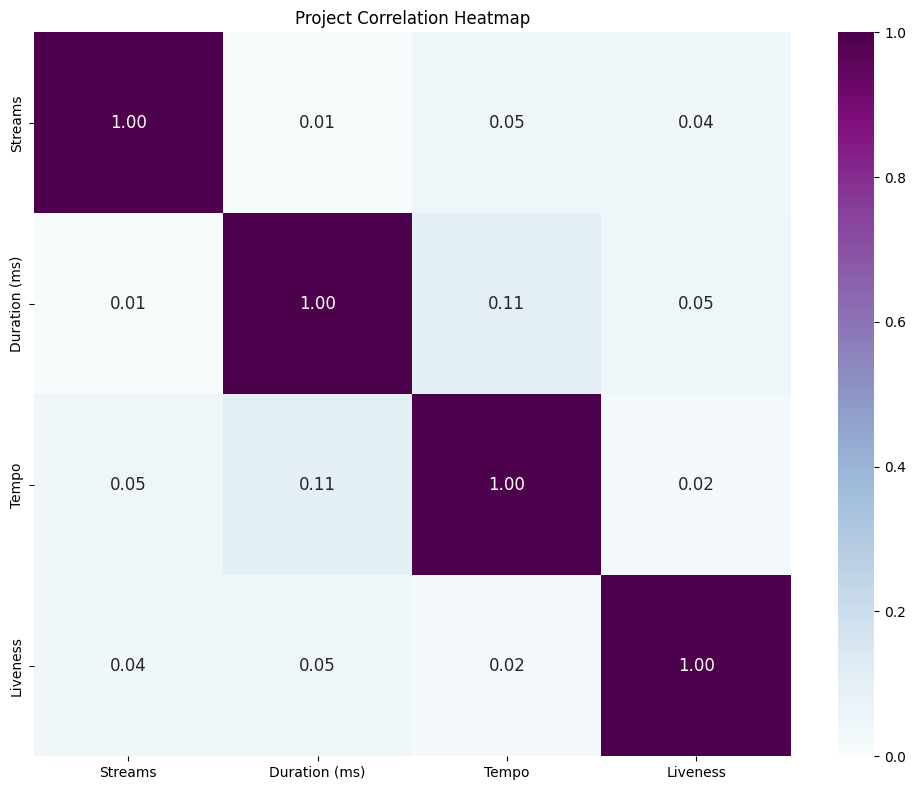

In [ ]:
 corr = df_clean.corr().abs().round(2)

plt.figure(figsize=(10,8))

 sns.heatmap(
    data=corr,
    annot=True, #Turns on the numbers in the boxes
    cmap='BuPu',
    vmin=0,
    vmax=1,
    annot_kws={"size": 12}, #Sets the font size of those numbers to 12
    fmt=".2f" #Formats the numbers to 2 decimal places
)

plt.title("Project Correlation Heatmap") #Update 'Project' with actual project definition

plt.tight_layout()
# plt.savefig("Corr.png")
plt.show()

###Histogram

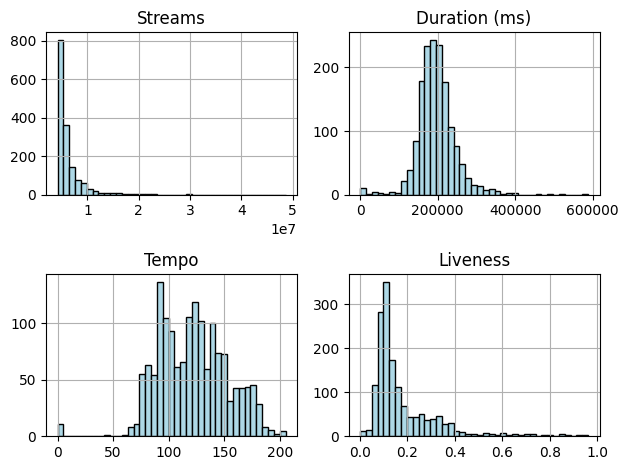

In [ ]:
n = int(1556**(1/2)) # bins

df_clean.hist(bins=n, color='lightblue', edgecolor='black')

plt.tight_layout()
plt.show()

###Boxplot

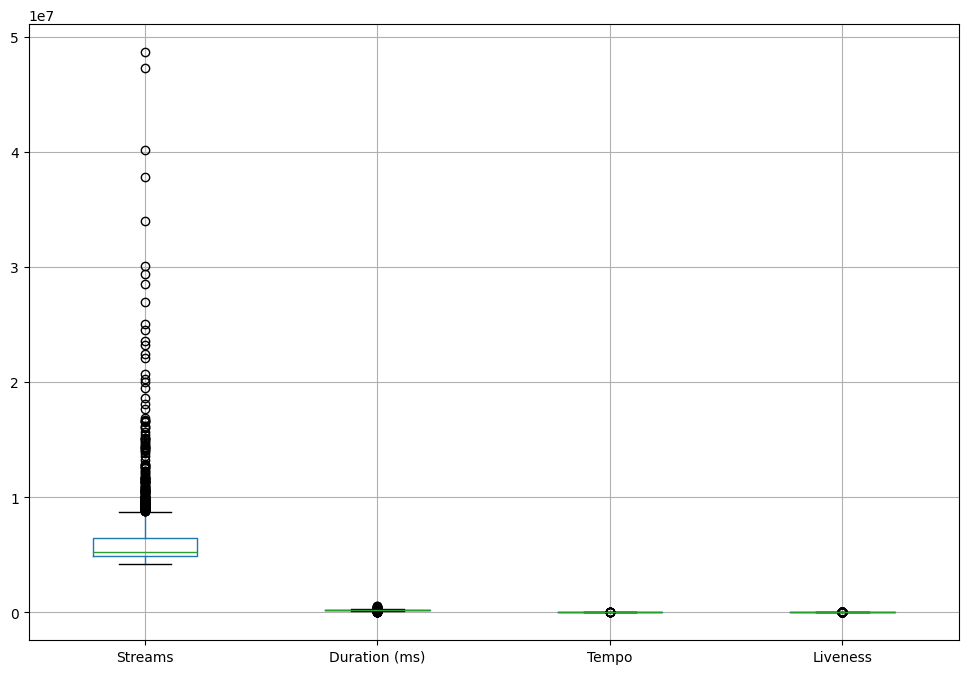

In [ ]:
plt.figure(figsize=(12,8))

df_clean.boxplot()
plt.show()

##Processing
Use modeling techniques to gain useful insights into data and meet objectives of the project.

- What questions did you ask to determine which ML process to use?
- How did/can you determine what performance metric to use?  What others could you have used?  Which metrics might not be appropriate?
- How did/can you account for the variance/bias trade-off?

Models we've learned so far:
- Naive Bayes
- Gaussian Naive Bayes
- Linear Regession
- Ridge Regulation
- Lasso Regulation

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn import datasets
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

In [ ]:
X = df_clean.drop(target, axis = 1)
y = df_clean[target]

###Decision Tree Regression

In [ ]:
numLoops = 500

rms_error = np.zeros(numLoops)

for idx in range(0,numLoops):
  X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)
  model = DecisionTreeRegressor(max_depth=3)         # Arbitrarily choosing max_depth of 3
  model.fit(X_train,y_train)
  y_pred = model.predict(X_test)
  rms_error[idx] = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"CV RMSE: {rms_error.mean().round(2)*1000}")

CV RMSE: 3423750630.0


####How do we choose the tree depth?

In [ ]:
max_depths = [1,2,3,4,5,6,7,8,9,10]
rms_depth = np.zeros(len(max_depths))
std_depth = np.zeros(len(max_depths))

numLoops = 500

for n, depth in enumerate(max_depths):
  rms_error = np.zeros(numLoops)

  for idx in range(0,numLoops):
    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)
    model = DecisionTreeRegressor(max_depth=depth)
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    rms_error[idx] = np.sqrt(mean_squared_error(y_test, y_pred))

  rms_depth[n] = rms_error.mean()
  std_depth[n] = rms_error.std(ddof = 1)

In [ ]:
pd.DataFrame(zip(max_depths, rms_depth, std_depth))

,0,1,2
0,1,3.309443e+06,629755.188554
1,2,3.357756e+06,595541.739881
2,3,3.432959e+06,584468.805377
3,4,3.597609e+06,634341.140416
4,5,3.711604e+06,688093.158471
5,6,3.981058e+06,674260.850249
6,7,4.209361e+06,736140.892054
7,8,4.306184e+06,696286.280645
8,9,4.432246e+06,733660.949970
9,10,4.519145e+06,680453.497814


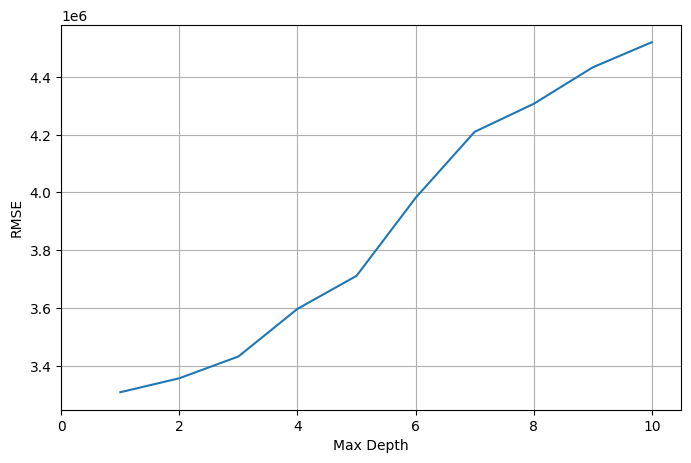

In [ ]:
 #Plot result
plt.figure(figsize = (8,5))
plt.plot(max_depths, rms_depth)
plt.xlabel('Max Depth')
plt.ylabel('RMSE')
plt.xlim(0, 10.5)
plt.grid()

In [ ]:
#Re run with max depth = 4
numLoops = 500

rms_error = np.zeros(numLoops)

for idx in range(0, numLoops):
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
  model = DecisionTreeRegressor(max_depth=4)
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  rms_error[idx] = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"CV RMSE: {rms_error.mean().round(2)*1000}")

CV RMSE: 3579531910.0


####Visualize the Decision Tree

In [ ]:
import graphviz
from IPython.display import display
from sklearn import tree

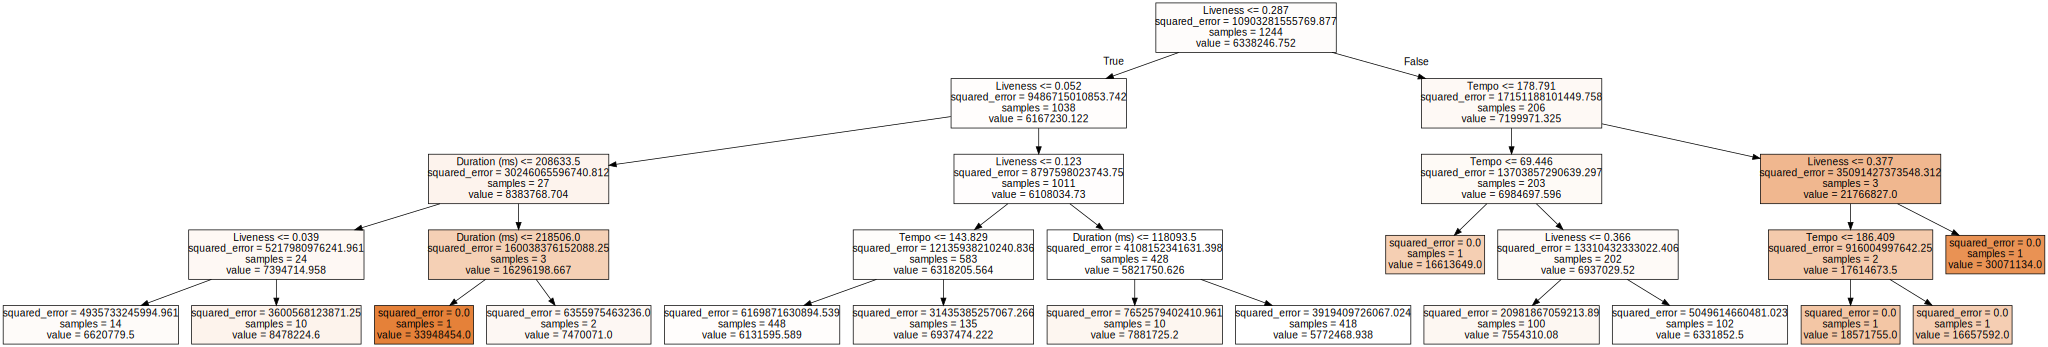

In [ ]:
#Readable view
display(
  graphviz.Source(
    tree.export_graphviz(
      model,
      feature_names = X.columns,
      filled = True,
    )
  )
)

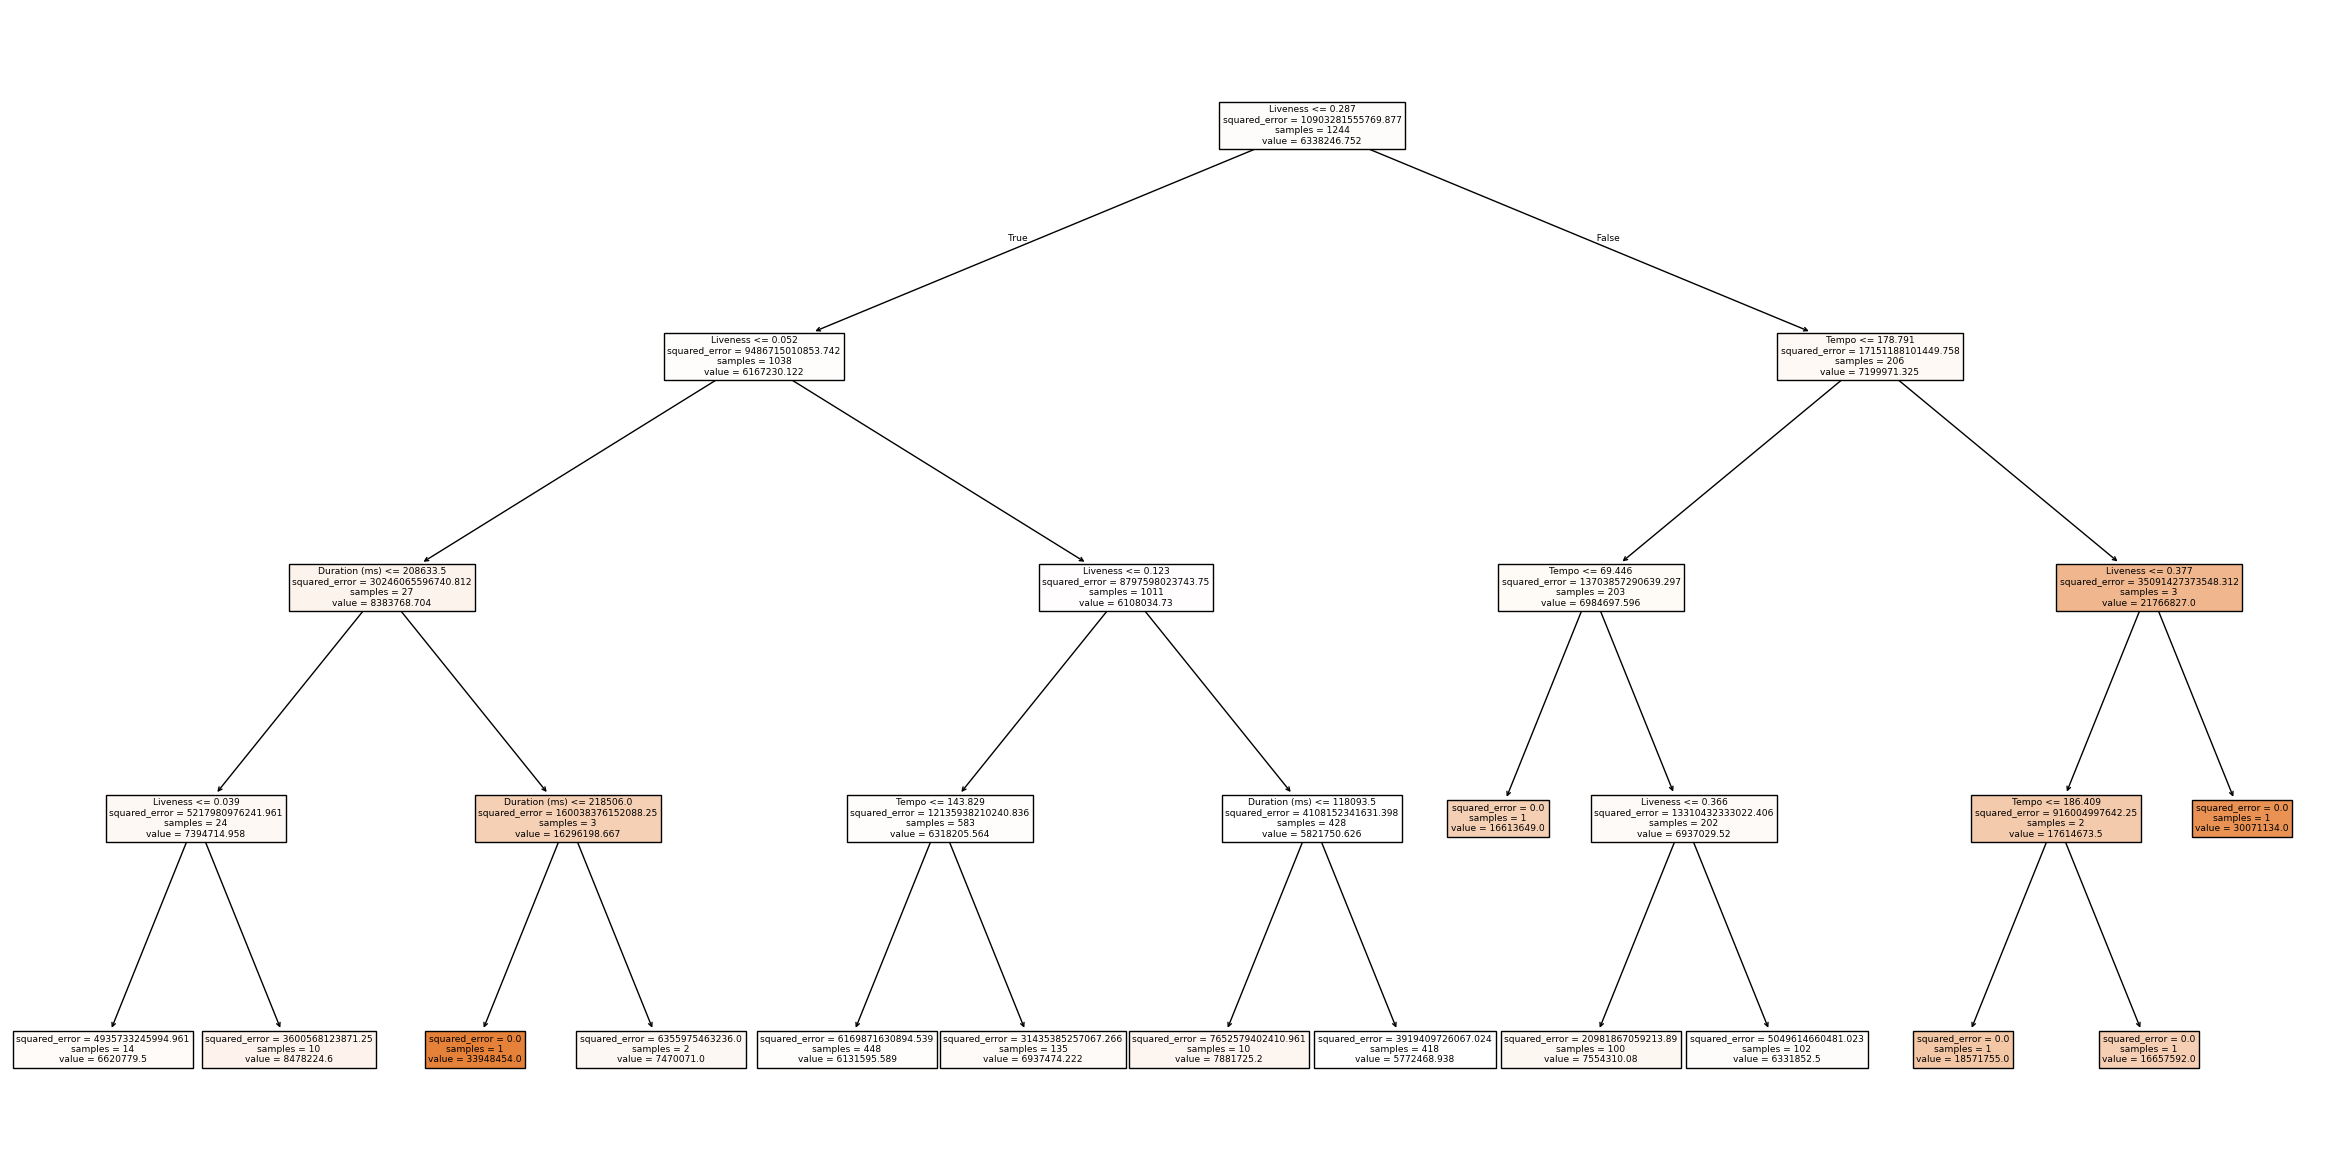

In [ ]:
#Full view
plt.figure(figsize=(30,15))
tree_plot = tree.plot_tree(
  model,
  feature_names = X.columns,
  filled=True,
)

###Random Tree

In [ ]:
from sklearn.ensemble import RandomForestRegressor
import pickle

In [ ]:
#This line intentionally left blank
numLoops = 500

mean_error = np.zeros(numLoops)

np.random.seed(42)
for idx in range(0,numLoops):
  X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)
  model = DecisionTreeRegressor(max_depth=4, random_state=0)
  model.fit(X_train,y_train)
  y_pred = model.predict(X_test)
  mean_error[idx] = mean_squared_error(y_test, y_pred)

print(f'RMSE: {np.sqrt(mean_error).mean()*1000}')
print(f'RMSE_std: {np.sqrt(mean_error).std()*1000}')

RMSE: 3566774893.7827845
RMSE_std: 628532428.336187


In [ ]:
#Two parameters - n_estimators (number of trees), max_depth (number of splits)
numLoops = 500

mean_error = np.zeros(numLoops)

# np.random.seed(42)
for idx in range(0,numLoops):
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)
  model = RandomForestRegressor(n_estimators = 10) # n_estimators is number of trees in forest. Note: you can also choose max_depth for RFs
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  mean_error[idx] = mean_squared_error(y_test, y_pred)

print(f'RMSE: {np.sqrt(mean_error).mean()*1000}')
print(f'RMSE_std: {np.sqrt(mean_error).std()*1000}')
np.sqrt(mean_error)[:50]

RMSE: 3696552492.3410454
RMSE_std: 525355919.77728254


array([4792704.34954367, 3073580.92456179, 5250246.68521881,
       3095638.61048171, 3233827.88724839, 2962107.15377062,
       4026111.21131267, 5033897.84697835, 3566522.02025387,
       3438188.26247154, 3640577.6249968 , 3676574.26841662,
       4042509.38083311, 4433177.73646212, 3354165.52888879,
       3010225.28451977, 3715170.9049645 , 3098813.02826219,
       3399804.21987568, 2943193.1465675 , 3309265.35702812,
       4172063.50191425, 3260641.85656346, 5065512.38840095,
       3101738.6446251 , 4132457.96359434, 3631072.95319427,
       4968749.36490509, 3200676.896052  , 2691245.37445238,
       4048008.43513675, 3414856.26546035, 4156468.57272222,
       3166081.79196996, 3279039.71568921, 3311045.78291284,
       3199589.93297141, 3740612.2818123 , 3724335.28472637,
       3192196.74959188, 3993121.22297572, 3317570.30635006,
       3934511.3381688 , 4142920.92582893, 4178997.7907103 ,
       3236487.40796963, 3390694.61090988, 3743829.59228049,
       3623398.13242741,

####How do you choose number of trees?

In [ ]:
num_trees = range(10,60,10)
cv_loops = 100
rmse_results = np.zeros(len(num_trees))
std_results = np.zeros(len(num_trees))

for n, trees in enumerate(num_trees):
  rmse_cv = np.zeros(cv_loops)
  np.random.seed(42)
  for i in range(cv_loops):
    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20)
    rfModel = RandomForestRegressor(n_estimators=trees)
    rfModel.fit(X_train, y_train)
    y_pred_rf = rfModel.predict(X_test)
    rmse_cv[i] = np.sqrt(mean_squared_error(y_test, y_pred_rf))

  print(trees,' trees finished.')
  rmse_results[n] = rmse_cv.mean()
  std_results[n] = rmse_cv.std()

10  trees finished.
20  trees finished.
30  trees finished.
40  trees finished.
50  trees finished.


In [ ]:
pickle.dump(rfModel, open('rfModel.p','wb'))

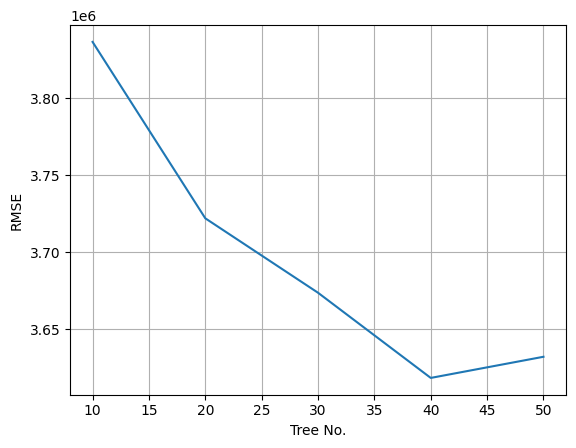

In [ ]:
plt.plot(num_trees, rmse_results)
plt.xlabel('Tree No.')
plt.ylabel('RMSE')
plt.grid()

In [ ]:
pd.DataFrame(zip(num_trees, rmse_results, std_results), columns='depth RMSE STDev'.split())

,depth,RMSE,STDev
0,10,3.836554e+06,516546.619167
1,20,3.721934e+06,561341.970120
2,30,3.673569e+06,592108.137940
3,40,3.618221e+06,579216.580121
4,50,3.631965e+06,547327.547306


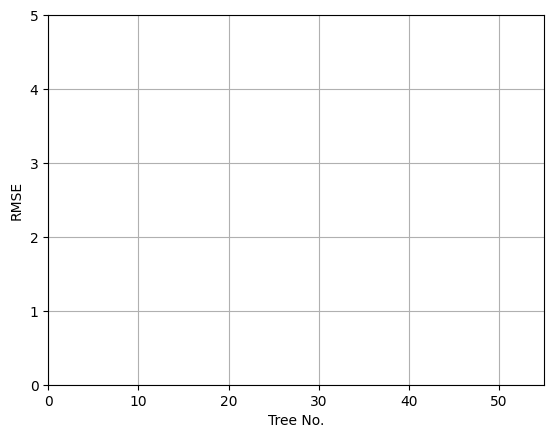

In [ ]:
# plt.errorbar(num_trees, rmse_results, yerr=(std_results*2,std_results*2))
plt.errorbar(num_trees, rmse_results, yerr=std_results)
plt.xlabel('Tree No.')
plt.ylabel('RMSE')
plt.ylim(0,5)
plt.xlim(0,55)
plt.grid()

In [ ]:
print(f'RMSE with 30 trees: {rmse_results[2]*1000}')

RMSE with 30 trees: 3673569155.4974


In [ ]:
import graphviz
from IPython.display import display
from sklearn import tree

In [ ]:
len(rfModel.estimators_)

50

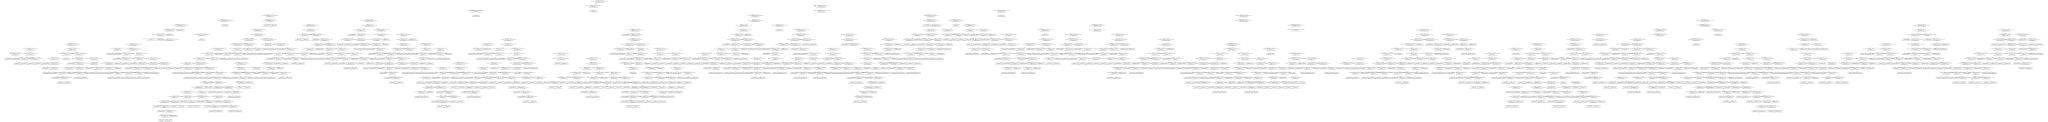

In [ ]:
#Display one tree from the random forest
display(
  graphviz.Source(
    tree.export_graphviz(
      rfModel.estimators_[0],
      feature_names = X.columns,
    )
  )
)

####Find Important Predictors

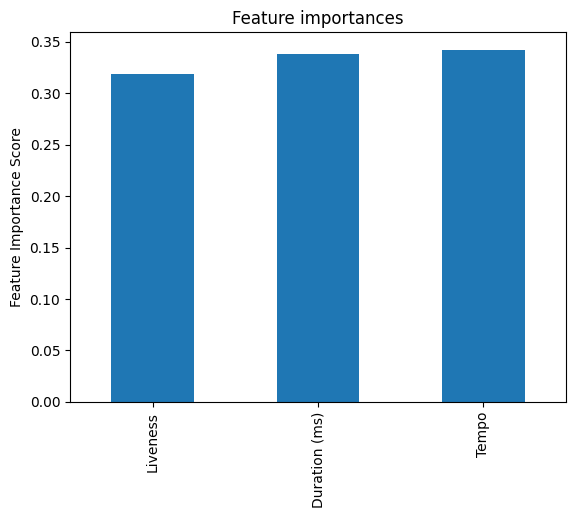

In [ ]:
importances = rfModel.feature_importances_
forest_importances = pd.Series(importances, index = X.columns)

plt.figure()
# forest_importances.plot.bar()
forest_importances.sort_values(ascending=True).plot.bar()
plt.title("Feature importances")
plt.ylabel('Feature Importance Score');

In [ ]:
(forest_importances.sort_values(ascending=False) * 100).cumsum()

,0
Tempo,34.225971
Duration (ms),68.099585
Liveness,100.000000


###XGBooster

In [ ]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV

In [ ]:
numLoops = 100
mse_xgb  = np.zeros(numLoops)

for idx in range(0,numLoops):
  X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.15)
  xgbr = xgb.XGBRegressor(objective ='reg:squarederror', verbosity=0, seed = 10)
  xgbr.fit(X_train,y_train)
  y_pred_xgb = xgbr.predict(X_test)
  mse_xgb[idx] = mean_squared_error(y_test,y_pred_xgb)

print(f'RMSE: {np.sqrt(mse_xgb).mean()*1000}')

RMSE: 3958968332.3537045


In [ ]:
y_pred_xgb[0]

np.float32(5125193.0)

In [ ]:
y_test.to_numpy()[0]

np.int64(5280810)

In [ ]:
my_house = X_test[:3]
my_house

,Duration (ms),Tempo,Liveness
1050,115200,133.928,0.1020
1055,309120,91.973,0.0935
222,207481,81.068,0.3700


In [ ]:
xgbr.predict(my_house)

array([5125193. , 6647999. , 6777977.5], dtype=float32)

In [ ]:
y_test[:3]

,Streams
1050,5280810
1055,4501188
222,6142975


###XGBoost with Parameters

In [ ]:
#Specify the parameters you want to try and their ranges.
param_test = {
 'max_depth'     : [3, 4, 5, 6, 7],
 'learning_rate' : [0.1, 0.2, 0.3, 0.4],
 'n_estimators'  : [20, 40, 60, 80, 100, 120, 140]
}

#Perform the grid search
#This is the Cross Validation (140)
gsearch = GridSearchCV(
    estimator = xgb.XGBRegressor(objective = 'reg:squarederror', seed = 10),
    param_grid = param_test,
    scoring = 'neg_mean_squared_error',
    cv = 5,
)

#Fit to training data
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.05, random_state = 42)
model = gsearch.fit(X_train,y_train)

#See grid search results
print(model.best_params_)

{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 20}


Now we will fit our XGBoost model with the best parameters

In [ ]:
params = model.best_params_

numLoops = 100
mse_xgb  = np.zeros(numLoops)

for idx in range(0,numLoops):
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.15)
  xgbr = xgb.XGBRegressor(
      objective ='reg:squarederror',
      verbosity=0,
      #Unpack a dictionary (* to unpack a list)
      **params,
      # learning_rate = 0.2,
      # max_depth = 3,
      # n_estimators = 100,
      seed = 10 #To be reproducable
  )
  xgbr.fit(X_train,y_train)
  y_pred_xgb = xgbr.predict(X_test)
  mse_xgb[idx] = mean_squared_error(y_test,y_pred_xgb)

print(f'RMSE: {np.sqrt(mse_xgb).mean()*1000}')

RMSE: 3269991390.244814


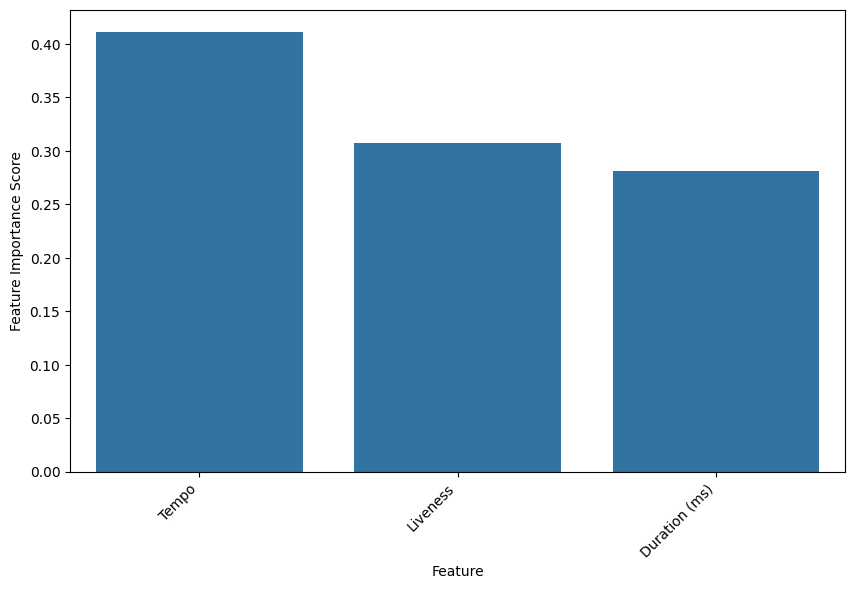

In [ ]:
feat_imp = pd.Series(xgbr.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize = (10,6))
sns.barplot(x = feat_imp.index, y = feat_imp.values)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Feature')
plt.ylabel('Feature Importance Score');

In [ ]:
(feat_imp.sort_values(ascending=False)*100).cumsum()

,0
Tempo,41.129944
Liveness,71.880539
Duration (ms),100.000000


##Conclusion and Future Work

Conclusions
  - RMSE went down

Future Work
  - Keep target
  - Use One-Hot Encodeing for objects
  - Re-evaluate features